In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("Churn_Modelling.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
l=[i for i in df.columns if df[i].dtype=='O']

In [9]:
l

['Surname', 'Geography', 'Gender']

In [10]:
df.drop('Surname',axis=1,inplace=True)

In [11]:
df.columns

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [12]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [13]:
df = pd.concat([df.drop('Geography', axis=1), pd.get_dummies(df['Geography'])], axis=1)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   CreditScore      10000 non-null  int64  
 3   Gender           10000 non-null  object 
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
 11  Exited           10000 non-null  int64  
 12  France           10000 non-null  bool   
 13  Germany          10000 non-null  bool   
 14  Spain            10000 non-null  bool   
dtypes: bool(3), float64(2), int64(9), object(1)
memory usage: 966.9+ KB


In [15]:
df=pd.concat([df.drop('Gender',axis=1),pd.get_dummies(df['Gender'])], axis=1)

In [16]:
df.columns

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'France', 'Germany', 'Spain', 'Female', 'Male'],
      dtype='object')

In [17]:
df['Male']

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [18]:
def s(x):
  if x==False:
    return 0
  else:
    return 1

In [19]:
df['Male']=df['Male'].apply(lambda x:s(x))

In [20]:
df['Male']

,Male
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,1
9997,0
9998,1


In [21]:
df['Gender']=df['Male']

In [22]:
df.drop('Male',axis=1,inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   CreditScore      10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
 11  France           10000 non-null  bool   
 12  Germany          10000 non-null  bool   
 13  Spain            10000 non-null  bool   
 14  Female           10000 non-null  bool   
 15  Gender           10000 non-null  int64  
dtypes: bool(4), float64(2), int64(10)
memory usage: 976.7 KB


In [24]:
df['France']=df['France'].apply(lambda x : s(x))
df['Germany']=df['Germany'].apply(lambda x : s(x))
df['Spain']=df['Spain'].apply(lambda x : s(x))

In [25]:
#df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)


In [26]:
df['France']

,France
0,1
1,0
2,1
3,1
4,0
...,...
9995,1
9996,1
9997,1
9998,0


In [27]:
df.drop('Female',inplace=True,axis=1)

In [28]:
df.drop(columns=['RowNumber','CustomerId'],inplace=True,axis=1)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Age              10000 non-null  int64  
 2   Tenure           10000 non-null  int64  
 3   Balance          10000 non-null  float64
 4   NumOfProducts    10000 non-null  int64  
 5   HasCrCard        10000 non-null  int64  
 6   IsActiveMember   10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Exited           10000 non-null  int64  
 9   France           10000 non-null  int64  
 10  Germany          10000 non-null  int64  
 11  Spain            10000 non-null  int64  
 12  Gender           10000 non-null  int64  
dtypes: float64(2), int64(11)
memory usage: 1015.8 KB


In [30]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(X_train)
x_test=scaler.transform(X_test)

In [32]:
inputs=layers.Input(shape=(12,))
layer1=layers.Dense(32,activation='relu')(inputs)
layer2=layers.Dense(64,activation='relu')(layer1)
layer3=layers.Dense(1,activation='sigmoid')(layer2)

In [33]:
model=models.Model(inputs=inputs,outputs=layer3)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593 (10.13 KB)

 Trainable params: 2,593 (10.13 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [44]:
history=model.fit(x_train,y_train,epochs=10,validation_split=0.2,shuffle=True)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8760 - loss: 0.2954 - val_accuracy: 0.8631 - val_loss: 0.3336
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8786 - loss: 0.2871 - val_accuracy: 0.8612 - val_loss: 0.3377
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8807 - loss: 0.2804 - val_accuracy: 0.8612 - val_loss: 0.3360
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8809 - loss: 0.2855 - val_accuracy: 0.8644 - val_loss: 0.3387
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8809 - loss: 0.2835 - val_accuracy: 0.8644 - val_loss: 0.3400
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8876 - loss: 0.2750 - val_accuracy: 0.8631 - val_loss: 0.3375
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8842 - loss: 0.2740 - val_accuracy: 0.8637 - val_loss: 0.3356
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8781 - loss: 0.2832 - val_accuracy: 0.

In [36]:
y_log=model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [37]:
y_log

array([[0.36044967],
       [0.28893295],
       [0.11792348],
       ...,
       [0.4355872 ],
       [0.24151914],
       [0.18337266]], dtype=float32)

In [38]:
y_pred=np.where(y_log>0.5,1,0)

In [39]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8605

/tmp/ipykernel_272/583510864.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


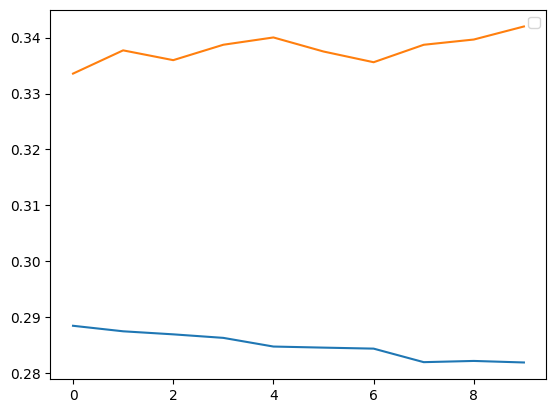

In [46]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend()